#  Crop Disease Detection using CNNs



---

##  CELL 1 — Install & import libraries


In [1]:
# Install any missing packages (Colab usually has these, but just in case)
!pip install torch torchvision matplotlib scikit-learn --quiet

# Import everything we need
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import zipfile
import time

# Check if GPU is available — Colab should give us one
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


##  CELL 2 — Download the PlantVillage dataset from Kaggle


In [2]:
import os
import json

# Paste your Kaggle username and API key here
# Find them in: kaggle.com → Profile → Settings → API → Create New Token
KAGGLE_USERNAME = "himandus"   # ← replace this
KAGGLE_KEY      = "KGAT_6cdeffa438a9d263998952e6766b8e68"    # ← replace this

# Create the kaggle.json file manually
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials set up successfully!")

Kaggle credentials set up successfully!


In [3]:
# Download the PlantVillage dataset (this takes ~2-3 minutes)
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

# Unzip it
print('Unzipping dataset...')
with zipfile.ZipFile('plantvillage-dataset.zip', 'r') as z:
    z.extractall('plantvillage')
print('Done! Dataset is ready.')

# Show the folder structure
data_dir = 'plantvillage/plantvillage dataset/color'
classes = sorted(os.listdir(data_dir))
print(f'\nTotal disease classes found: {len(classes)}')
print('First 5 classes:', classes[:5])

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [02:10<00:00, 16.8MB/s]

Unzipping dataset...
Done! Dataset is ready.

Total disease classes found: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


##  CELL 3 — Preview some images
.

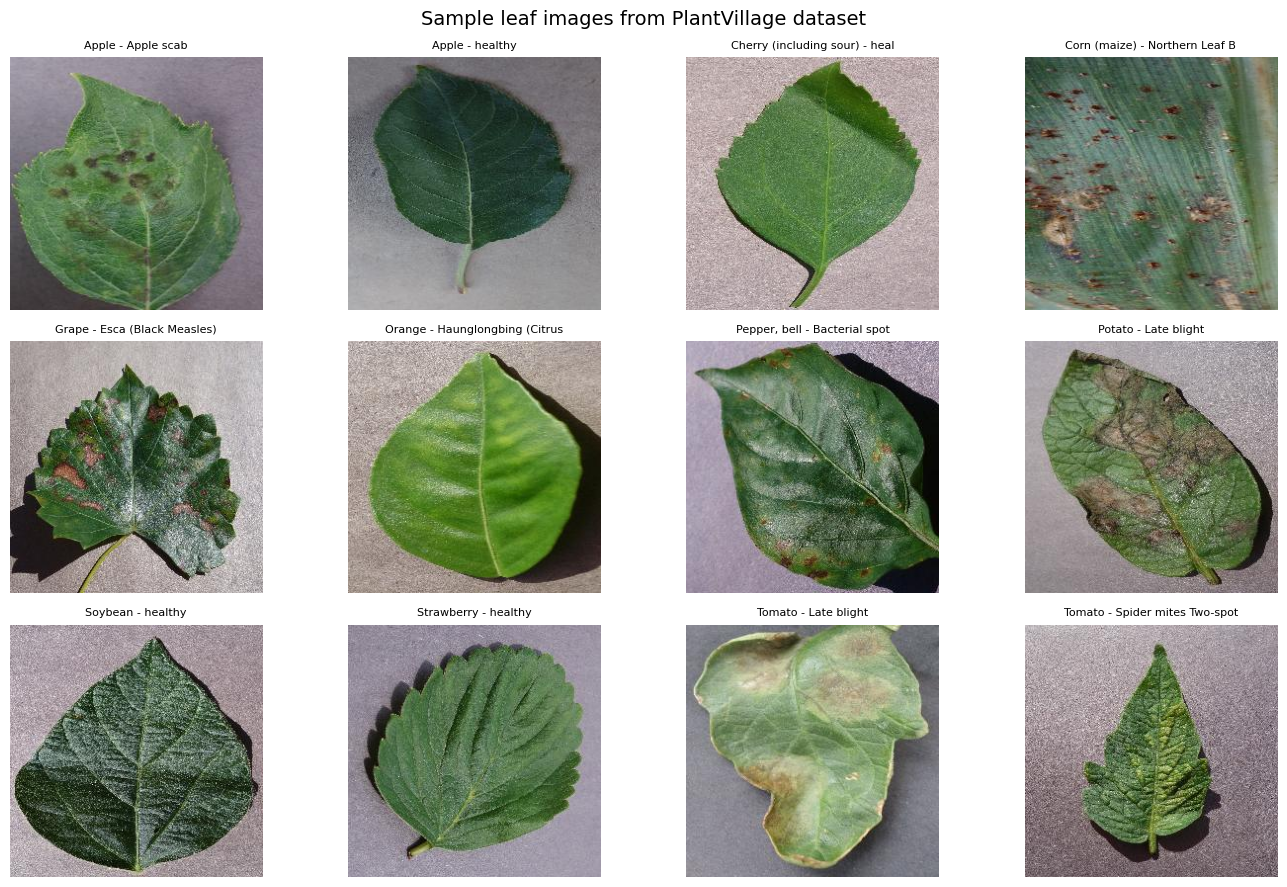

In [4]:
# Show 12 sample images from the dataset so we can see what we're working with
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Sample leaf images from PlantVillage dataset', fontsize=14)

for i, ax in enumerate(axes.flat):
    # Pick a random class and a random image from it
    cls = classes[i * (len(classes) // 12)]
    cls_path = os.path.join(data_dir, cls)
    img_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_file))
    ax.imshow(img)
    # Shorten the class name so it fits
    label = cls.replace('___', ' - ').replace('_', ' ')
    ax.set_title(label[:30], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## CELL 4 — Prepare the data (preprocessing + augmentation)


In [5]:
# --- Transforms ---
# Training images get augmentation (random flips/rotations) to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),          # randomly mirror left-right
    transforms.RandomVerticalFlip(),            # randomly mirror up-down
    transforms.RandomRotation(20),              # randomly rotate up to 20 degrees
    transforms.ColorJitter(brightness=0.2,      # slightly change brightness/contrast
                           contrast=0.2),
    transforms.ToTensor(),                      # convert image to numbers
    transforms.Normalize([0.485, 0.456, 0.406], # these numbers are the ImageNet mean
                         [0.229, 0.224, 0.225]) # and std — standard for pretrained models
])

# Validation/test images don't get augmentation — just resize and normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- Load the full dataset ---
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f'Total images: {len(full_dataset)}')
print(f'Number of classes: {num_classes}')

# --- Split into train / val / test ---
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # fix seed for reproducibility
)

# Apply the correct transform to each split
val_ds.dataset.transform  = val_transform
test_ds.dataset.transform = val_transform

print(f'\nTrain set:      {len(train_ds)} images')
print(f'Validation set: {len(val_ds)} images')
print(f'Test set:       {len(test_ds)} images')

# --- Create data loaders (these feed batches to the model) ---
BATCH_SIZE = 32  # process 32 images at a time

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('\nData loaders ready!')

Total images: 54305
Number of classes: 38

Train set:      38013 images
Validation set: 8145 images
Test set:       8147 images

Data loaders ready!


##  CELL 5 — Build the model (transfer learning with EfficientNetB0)


In [ ]:
# Choose which model to use
# Options: 'efficientnet' (best accuracy), 'resnet50' (balanced), 'mobilenet' (fastest)
MODEL_CHOICE = 'efficientnet'   # <-- change this to try different architectures

def build_model(choice, num_classes):
    if choice == 'efficientnet':
        # EfficientNetB0 — best accuracy, small size
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        # Replace the final classification layer
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif choice == 'resnet50':
        # ResNet50 — very popular, well-documented
        model = models.resnet50(weights='IMAGENET1K_V1')
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif choice == 'mobilenet':
        # MobileNetV2 — smallest and fastest, good for phones
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    # Freeze all layers except the final one
    # (We only want to train the new classification head)
    for name, param in model.named_parameters():
        if 'classifier' not in name and 'fc' not in name:
            param.requires_grad = False

    return model

model = build_model(MODEL_CHOICE, num_classes)
model = model.to(device)  # move model to GPU

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model: {MODEL_CHOICE}')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}  ({100*trainable/total_params:.1f}% of total)')
print('Model ready!')

Model: efficientnet
Total parameters:     4,056,226
Trainable parameters: 685,218  (16.9% of total)
Model ready!


##  CELL 6 — Set up training (loss function + optimizer)


In [ ]:
# Loss function: CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam is reliable and works well out-of-the-box
# We only optimize the trainable (unfrozen) parameters
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001  # learning rate — how big each update step is
)

# Learning rate scheduler: reduce LR by 10x if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.1
)

print('Loss function:', criterion)
print('Optimizer:', type(optimizer).__name__)
print('All set — ready to train!')

Loss function: CrossEntropyLoss()
Optimizer: Adam
All set — ready to train!


## 🏋️CELL 7 — Train the model


In [ ]:
NUM_EPOCHS = 10  # number of full passes through the training data
                 # increase to 20 for better results (takes longer)

# Track metrics for plotting later
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ---- Training phase ----
    model.train()  # set model to training mode
    train_loss, train_correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        # clear gradients from previous step
        outputs = model(images)      # forward pass: make predictions
        loss = criterion(outputs, labels)  # calculate how wrong we are
        loss.backward()              # backward pass: calculate gradients
        optimizer.step()             # update model weights

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    # ---- Validation phase ----
    model.eval()  # set model to evaluation mode (disables dropout etc.)
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():  # don't track gradients during validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()

    # Calculate epoch averages
    train_loss_avg = train_loss / len(train_ds)
    val_loss_avg   = val_loss   / len(val_ds)
    train_acc      = 100 * train_correct / len(train_ds)
    val_acc        = 100 * val_correct   / len(val_ds)
    elapsed        = time.time() - start_time

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    # Update scheduler
    scheduler.step(val_loss_avg)

    # Record history
    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | '
          f'Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}% | '
          f'Time: {elapsed:.0f}s')

print('=' * 60)
print(f'Training complete! Best validation accuracy: {best_val_acc:.2f}%')

Training for 10 epochs on cuda...
Epoch [ 1/10] | Train Loss: 0.2526 | Train Acc: 93.68% | Val Loss: 0.0331 | Val Acc: 98.90% | Time: 182s
Epoch [ 2/10] | Train Loss: 0.0514 | Train Acc: 98.36% | Val Loss: 0.0287 | Val Acc: 99.02% | Time: 175s
Epoch [ 3/10] | Train Loss: 0.0379 | Train Acc: 98.84% | Val Loss: 0.0196 | Val Acc: 99.36% | Time: 175s
Epoch [ 4/10] | Train Loss: 0.0281 | Train Acc: 99.08% | Val Loss: 0.0225 | Val Acc: 99.44% | Time: 174s
Epoch [ 5/10] | Train Loss: 0.0215 | Train Acc: 99.32% | Val Loss: 0.0148 | Val Acc: 99.53% | Time: 173s
Epoch [ 6/10] | Train Loss: 0.0234 | Train Acc: 99.24% | Val Loss: 0.0148 | Val Acc: 99.55% | Time: 175s
Epoch [ 7/10] | Train Loss: 0.0173 | Train Acc: 99.44% | Val Loss: 0.0151 | Val Acc: 99.51% | Time: 173s
Epoch [ 8/10] | Train Loss: 0.0177 | Train Acc: 99.40% | Val Loss: 0.0227 | Val Acc: 99.31% | Time: 175s
Epoch [ 9/10] | Train Loss: 0.0170 | Train Acc: 99.44% | Val Loss: 0.0151 | Val Acc: 99.56% | Time: 174s
Epoch [10/10] | Train

##  CELL 8 — Plot training curves


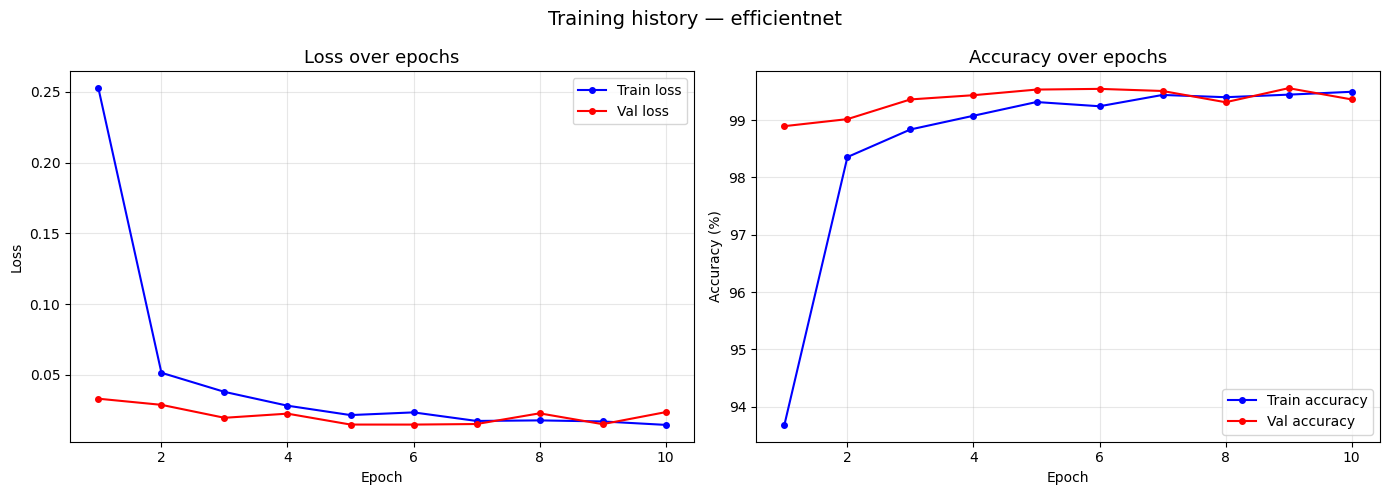

Chart saved as training_curves.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss curve
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train loss', markersize=4)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val loss',   markersize=4)
ax1.set_title('Loss over epochs', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train accuracy', markersize=4)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Val accuracy',   markersize=4)
ax2.set_title('Accuracy over epochs', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Training history — {MODEL_CHOICE}', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as training_curves.png')

##  CELL 9 — Evaluate on the test set


In [ ]:
# Load the best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
test_acc = 100 * (all_preds == all_labels).sum() / len(all_labels)
print(f'Test Accuracy: {test_acc:.2f}%')
print()

# Detailed report: precision, recall, F1 per class
# This is what you put in Table 2 of your research paper!
print('Per-class metrics (use this in your paper):')
print('-' * 60)
report = classification_report(
    all_labels, all_preds,
    target_names=[c.replace('___', ' — ') for c in class_names],
    digits=3
)
print(report)

Test Accuracy: 99.47%

Per-class metrics (use this in your paper):
------------------------------------------------------------
                                                    precision    recall  f1-score   support

                                Apple — Apple_scab      1.000     0.989     0.994        91
                                 Apple — Black_rot      1.000     1.000     1.000        87
                          Apple — Cedar_apple_rust      1.000     1.000     1.000        37
                                   Apple — healthy      1.000     0.993     0.996       270
                               Blueberry — healthy      0.995     0.995     0.995       198
          Cherry_(including_sour) — Powdery_mildew      1.000     1.000     1.000       176
                 Cherry_(including_sour) — healthy      0.992     0.992     0.992       125
Corn_(maize) — Cercospora_leaf_spot Gray_leaf_spot      0.956     0.915     0.935        71
                       Corn_(maize) — Commo

CELL 10 - CONFUSION Matrix

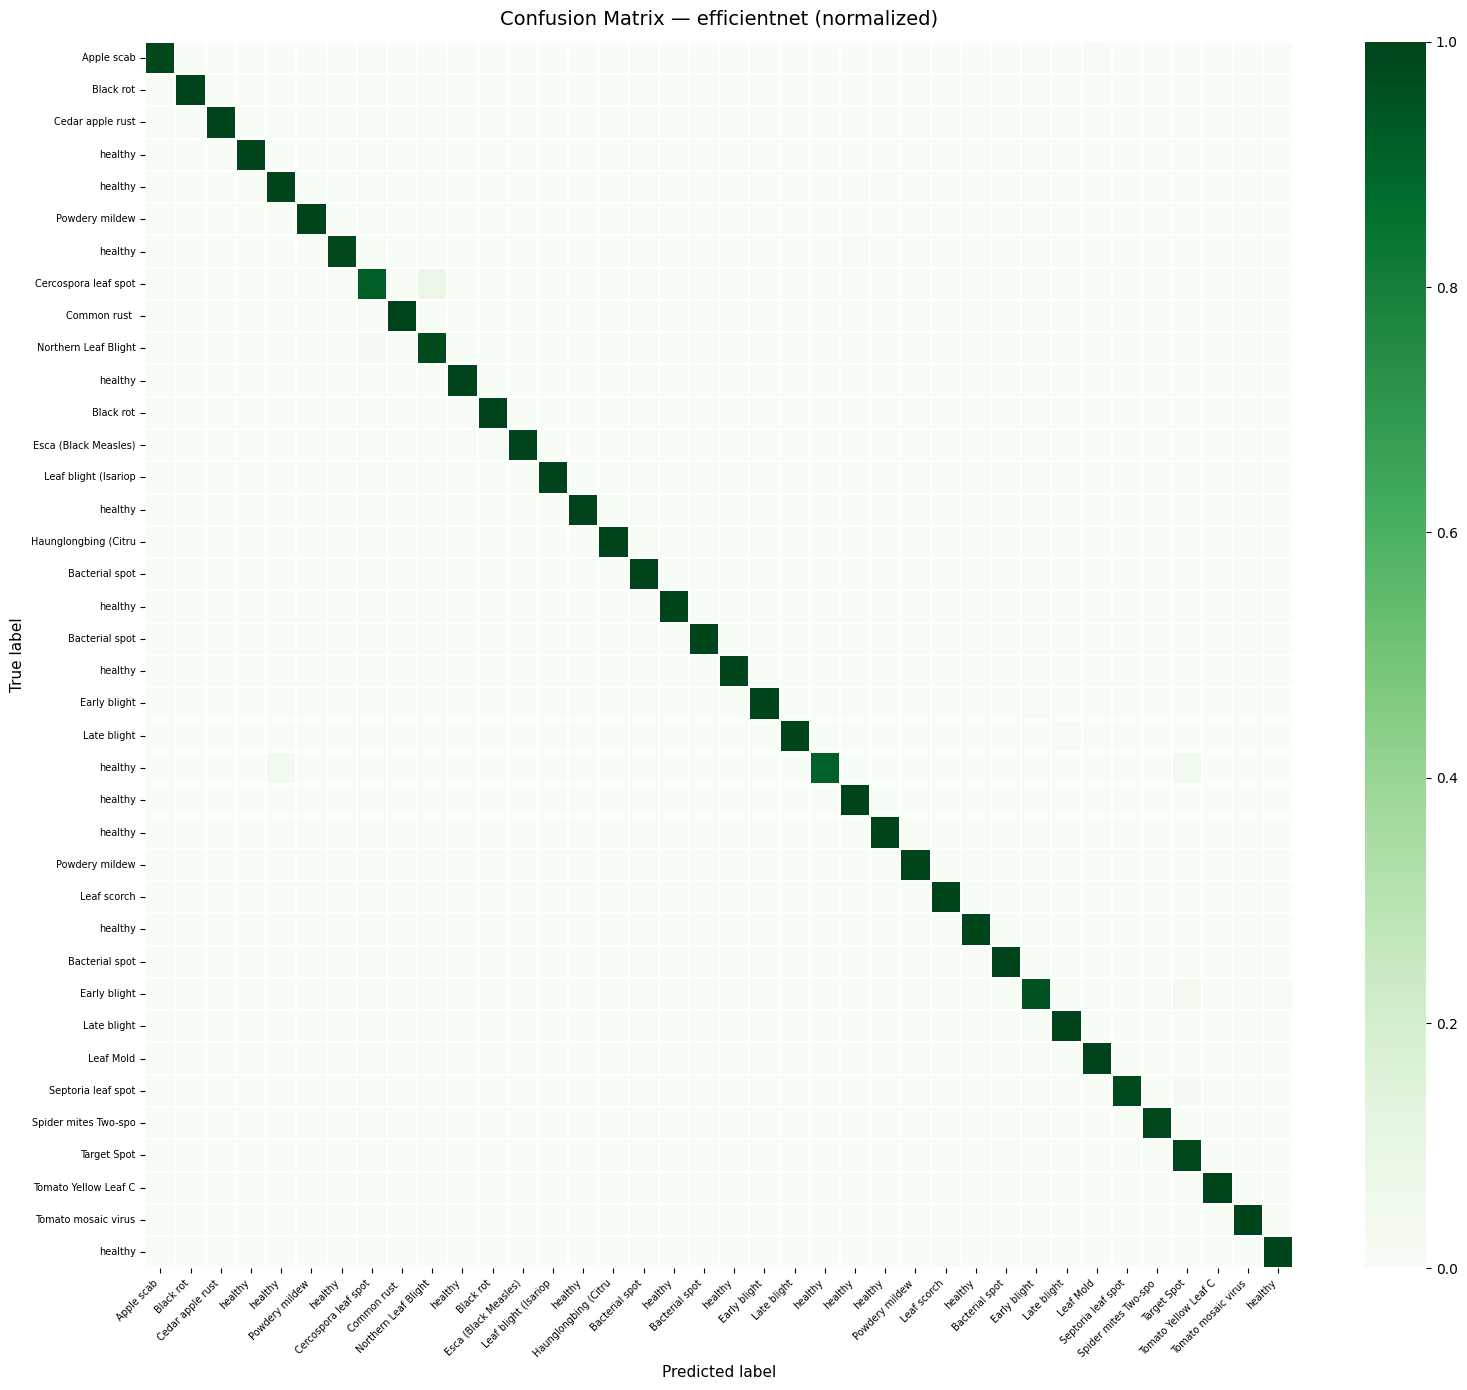

Confusion matrix saved as confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

# Normalize so each row sums to 1 (shows % instead of counts)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

short_names = [c.split('___')[-1].replace('_', ' ')[:20] for c in class_names]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm, annot=False, fmt='.2f',
    cmap='Greens', ax=ax,
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.3, linecolor='white'
)
ax.set_title(f'Confusion Matrix — {MODEL_CHOICE} (normalized)', fontsize=14, pad=12)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved as confusion_matrix.png')

## 🔥 CELL 11 — Grad-CAM visualisation (bonus!)
Grad-CAM shows **which part of the leaf** the model looked at when making a prediction. This is a great addition to your research paper — it proves the model learned meaningful features (disease spots), not background noise.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


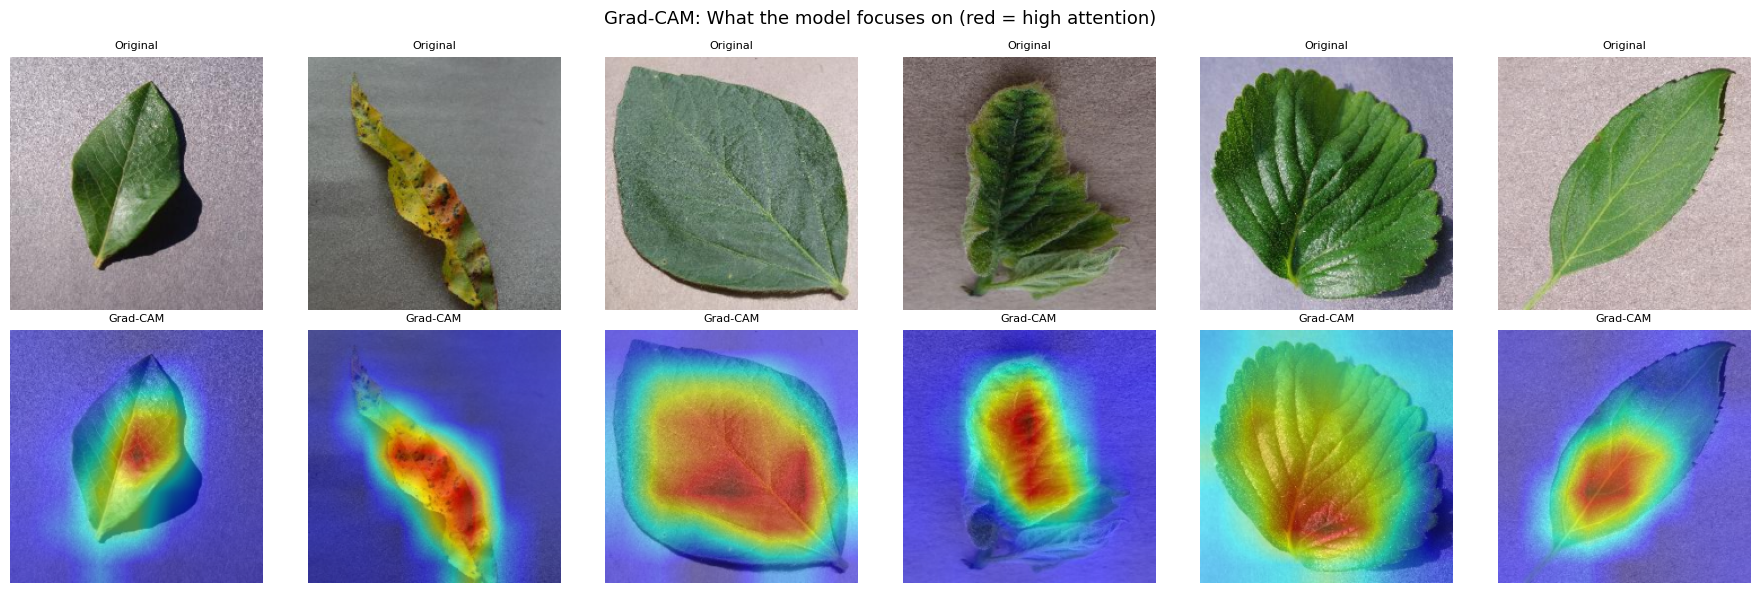

Grad-CAM visualisation saved as gradcam.png


In [ ]:
!pip install grad-cam --quiet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Pick the last convolutional layer (the one Grad-CAM hooks into)
if MODEL_CHOICE == 'efficientnet':
    target_layers = [model.features[-1]]
elif MODEL_CHOICE == 'resnet50':
    target_layers = [model.layer4[-1]]
elif MODEL_CHOICE == 'mobilenet':
    target_layers = [model.features[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# Get a few test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:6]  # visualise 6 images

# Unnormalise images for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Grad-CAM: What the model focuses on (red = high attention)', fontsize=13)

for i, img_tensor in enumerate(test_images):
    # Original image
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)

    # Grad-CAM heatmap
    grayscale_cam = cam(input_tensor=img_tensor.unsqueeze(0).to(device))[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0, i].imshow(img_np)
    axes[0, i].set_title('Original', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_image)
    axes[1, i].set_title('Grad-CAM', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM visualisation saved as gradcam.png')

## CELL 12 — Save the model and download results


In [ ]:
from google.colab import files

# Save a summary of results to a text file
with open('results_summary.txt', 'w') as f:
    f.write(f'Model: {MODEL_CHOICE}\n')
    f.write(f'Test Accuracy: {test_acc:.2f}%\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.2f}%\n')
    f.write(f'Num Classes: {num_classes}\n')
    f.write(f'Num Epochs: {NUM_EPOCHS}\n')
    f.write('\nPer-class report:\n')
    f.write(report)

# Download everything
print('Downloading results...')
for fname in ['best_model.pth', 'training_curves.png',
               'confusion_matrix.png', 'gradcam.png', 'results_summary.txt']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Downloaded: {fname}')

print('\nAll done! Check your Downloads folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: gradcam.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: results_summary.txt

All done! Check your Downloads folder.
